# Bei Smart — Price-Level Classification (XGBoost)
### Kenya Food Price Intelligence System

This notebook builds a multi-class classifier that predicts whether a given
price observation is **Cheap**, **Average**, or **Expensive**, using
`data/cleaned/bei_smart_classification.csv` — the team's classification-ready
dataset (2016–2026, with fuel prices and rolling price features).

**Target**: `price_label` (Cheap / Average / Expensive)

**Models**: Logistic Regression (baseline) and XGBoost (main model), both
with class-imbalance handling, compared on held-out future data.

**Pipeline, in order:** outlier handling on `price_per_kg` → log-transform →
drop `usdprice` (and other leakage/redundant columns) → define target and
key features → apply class weights.

**A leakage note up front:** `price_vs_regional_avg` is the ratio used to
*construct* `price_label` in the first place (Cheap ≲0.90, Average
≈0.90–1.10, Expensive ≳1.10) — including it as a feature would let the
model just learn the threshold rule and score ~100%, which tells us nothing
useful. It stays excluded below. `price_per_kg` itself is **not**
deterministic of the label (it only becomes the label once divided by a
regional/commodity average), so it's kept as a feature — capped for
outliers and log-transformed, per noted skew of 2.55.


## 1. Setup

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, balanced_accuracy_score
)
from sklearn.utils.class_weight import compute_sample_weight

import xgboost as xgb

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load data

In [21]:
df = pd.read_csv(
    "../../data/cleaned/bei_smart_classification.csv",
    parse_dates=["date", "date_month"],
)
print(f"{df.shape[0]:,} rows x {df.shape[1]} cols")

# Drop rows with missing fuel prices (consistent with the team's master EDA)
df = df.dropna(subset=["diesel_price_kes"])
print(f"After dropping missing diesel_price_kes: {df.shape[0]:,} rows")

df.head()


27,316 rows x 19 cols


KeyError: ['diesel_price_kes']

Target distribution:
price_label
Low       9253
High      9097
Medium    8966
Name: count, dtype: int64

price_label
Low       33.9
High      33.3
Medium    32.8
Name: proportion, dtype: float64


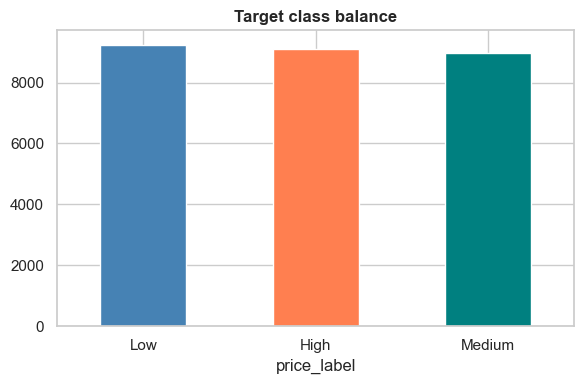

In [23]:
print("Target distribution:")
print(df['price_label'].value_counts())
print()
print(df['price_label'].value_counts(normalize=True).round(3) * 100)

fig, ax = plt.subplots(figsize=(6, 4))
df['price_label'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'coral', 'teal'])
ax.set_title("Target class balance")
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## 3. Outlier handling — `price_per_kg`

`price_per_kg` spans very different scales across commodities (e.g. spices
vs. maize), so a *global* IQR would flag entire cheap or expensive
commodities as outliers rather than genuine data errors. Outliers are
instead capped **within each commodity** using the 1.5×IQR rule.

In [ ]:
Q1 = df.groupby('commodity')['price_per_kg'].transform(lambda x: x.quantile(0.25))
Q3 = df.groupby('commodity')['price_per_kg'].transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

is_outlier = (df['price_per_kg'] < lower_bound) | (df['price_per_kg'] > upper_bound)
print(f"Outliers flagged (per-commodity IQR): {is_outlier.sum():,} rows ({is_outlier.mean():.2%})")
print()
print("Outliers by price_label:")
print(df.loc[is_outlier, 'price_label'].value_counts())

df['price_per_kg_capped'] = df['price_per_kg'].clip(lower=lower_bound, upper=upper_bound)


KeyError: 'Column not found: price_per_kg'

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['price_per_kg'], ax=axes[0], color="coral")
axes[0].set_title("price_per_kg — before capping")
sns.boxplot(x=df['price_per_kg_capped'], ax=axes[1], color="steelblue")
axes[1].set_title("price_per_kg — after per-commodity capping")
plt.tight_layout()
plt.show()


## 4. Log-transform

`price_per_kg` has a skew of ~2.55 (confirmed below) — heavily right-skewed,
as expected for prices. Log-transforming the capped values gives a more
symmetric distribution for the linear baseline in particular.

In [ ]:
from scipy.stats import skew

print(f"Skew before capping:        {skew(df['price_per_kg']):.3f}")
print(f"Skew after capping:         {skew(df['price_per_kg_capped']):.3f}")

df['log_price_per_kg'] = np.log1p(df['price_per_kg_capped'])
print(f"Skew after log-transform:   {skew(df['log_price_per_kg']):.3f}")


KeyError: 'price_per_kg'

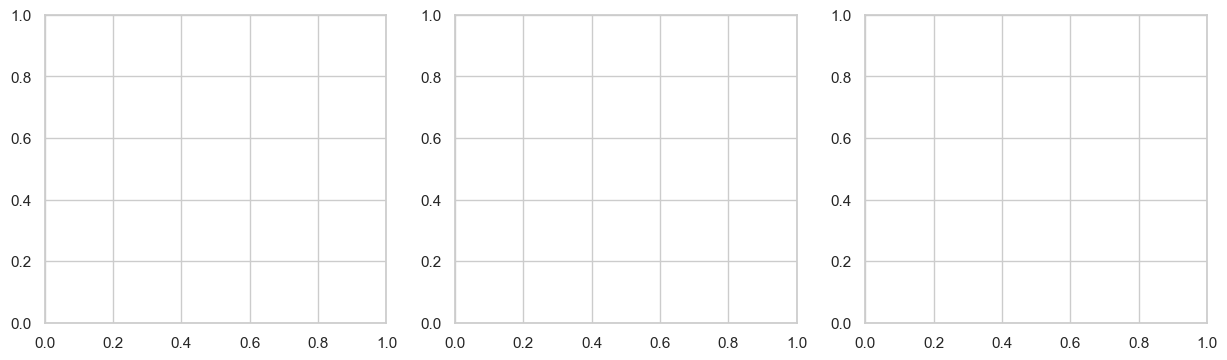

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['price_per_kg'], bins=50, ax=axes[0], color="coral")
axes[0].set_title("Original")
sns.histplot(df['price_per_kg_capped'], bins=50, ax=axes[1], color="teal")
axes[1].set_title("Outlier-capped")
sns.histplot(df['log_price_per_kg'], bins=50, ax=axes[2], color="steelblue")
axes[2].set_title("Capped + log-transformed")
plt.tight_layout()
plt.show()


## 5. Define target and key features

Columns dropped and why:

| Column | Reason |
|---|---|
| `price_vs_regional_avg` | **Leakage** — deterministically defines `price_label` (ratio thresholds) |
| `usdprice` | Redundant with `price`/`price_per_kg` (same signal, different currency) |
| `price`, `price_per_kg` (raw) | Superseded by `log_price_per_kg` (outlier-capped, log-transformed) |
| `rolling_3m_avg`, `rolling_6m_avg` | Highly correlated (>0.85) with `rolling_12m_avg` — flagged in the team's correlation analysis |
| `petrol_price_kes` | Highly correlated with `diesel_price_kes` |
| `pricetype`, `currency` | Constant (Retail / KES only) |
| `date`, `date_month`, `market_id`, `commodity_id` | Identifiers / redundant with other categorical columns |

**Key features kept**: `region`, `county`, `market`, `category`, `commodity`,
`season`, `month`, `year`, `rainfall_mm`, `diesel_price_kes`,
`rolling_12m_avg`, `latitude`, `longitude`, `priceflag`, and the new
`log_price_per_kg`.

**Target**: `price_label`.

In [ ]:
drop_cols = [
    'price_vs_regional_avg', 'price_per_kg', 'price_per_kg_capped', 'price', 'usdprice',
    'rolling_3m_avg', 'rolling_6m_avg', 'petrol_price_kes',
    'pricetype', 'currency', 'date', 'date_month',
    'market_id', 'commodity_id', 'unit',
]
target_col = 'price_label'

feature_df = df.drop(columns=drop_cols)
print("Remaining columns:", list(feature_df.columns))


In [ ]:
categorical_cols = ['region', 'county', 'market', 'category', 'commodity', 'season', 'priceflag']
numeric_cols = ['month', 'year', 'rainfall_mm', 'diesel_price_kes', 'rolling_12m_avg',
                'latitude', 'longitude', 'log_price_per_kg']

print(f"Categorical: {categorical_cols}")
print(f"Numeric: {numeric_cols}")

# quick null check on the features we're keeping
feature_df[categorical_cols + numeric_cols].isna().sum()[lambda s: s > 0]


## 6. Encode features & target

In [22]:
encoders = {}
X = feature_df[categorical_cols + numeric_cols].copy()

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(feature_df[target_col])
print("Classes:", list(label_encoder.classes_), "-> encoded as", list(range(len(label_encoder.classes_))))

X.head()


NameError: name 'feature_df' is not defined

## 7. Train/test split — time-based

A random split would let rows from the same market/commodity/month leak
between train and test via the rolling average features. Instead, split on
time: train on data through end of 2024, test on 2025–2026 — this mimics
how the model would actually be used (predicting on new, unseen months).

In [ ]:
df_reset = feature_df.reset_index(drop=True)
X_reset = X.reset_index(drop=True)

train_mask = df_reset['year'] <= 2024
test_mask = ~train_mask

X_train, X_test = X_reset[train_mask], X_reset[test_mask]
y_train, y_test = y[train_mask.values], y[test_mask.values]

print(f"Train: {X_train.shape[0]:,} rows ({df_reset[train_mask]['year'].min()}-{df_reset[train_mask]['year'].max()})")
print(f"Test:  {X_test.shape[0]:,} rows ({df_reset[test_mask]['year'].min()}-{df_reset[test_mask]['year'].max()})")
print()
print("Train class balance:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))
print("\nTest class balance:")
print(pd.Series(y_test).value_counts(normalize=True).round(3))


## 8. Baseline model — Logistic Regression

A simple, interpretable baseline with `class_weight='balanced'` to handle
the ~2:1:1 class imbalance, before moving to XGBoost.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(
    class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_lr):.3f}")


## 9. XGBoost — main model

XGBoost handles the mixed categorical/numeric features without scaling, and
`sample_weight` (from `compute_sample_weight`) reproduces the same
class-balancing idea as `class_weight='balanced'` for a multi-class
objective.

In [ ]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(label_encoder.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_clf.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_xgb = xgb_clf.predict(X_test)

print(classification_report(y_test, y_pred_xgb, target_names=label_encoder.classes_))
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_xgb):.3f}")


## 10. Hyperparameter tuning

A light randomized search over the key XGBoost parameters, using stratified
CV within the training set (time-based test set stays untouched).

**A note on CV strategy:** the search below originally used a shuffled
`StratifiedKFold`, which returned a best CV macro-F1 of **0.84** — well
above the held-out 2025-2026 macro-F1 of 0.65. That gap meant the shuffled
folds were letting the model peek at patterns from surrounding time
periods, so the CV score wasn't a trustworthy estimate of future
performance. Switching to `TimeSeriesSplit` (below) brought CV macro-F1
down to **0.63** — much closer to the actual test score — at the cost of
a slightly lower test accuracy (0.71 -> 0.67), since the resulting params
are more regularized and less overfit to the training period.

In [ ]:
param_dist = {
    'n_estimators': [150, 300, 500, 800],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.5, 1],
    'reg_lambda': [1, 2, 5],
    'reg_alpha': [0, 0.5, 1],
}

base_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(label_encoder.classes_),
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# TimeSeriesSplit instead of shuffled StratifiedKFold -- respects the
# forward-in-time nature of the problem, so CV score reflects genuine
# held-out performance rather than an inflated shuffled-fold estimate
tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    base_model, param_distributions=param_dist, n_iter=30,
    scoring='f1_macro', cv=tscv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
search.fit(X_train, y_train, sample_weight=sample_weights)

print("Best params:", search.best_params_)
print(f"Best CV macro-F1 (TimeSeriesSplit): {search.best_score_:.3f}")


In [ ]:
best_xgb = search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_best):.3f}")
print(f"Macro F1: {f1_score(y_test, y_pred_best, average='macro'):.3f}")


## 11. Model comparison

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost (default)', 'XGBoost (tuned)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_best),
    ],
    'Balanced Accuracy': [
        balanced_accuracy_score(y_test, y_pred_lr),
        balanced_accuracy_score(y_test, y_pred_xgb),
        balanced_accuracy_score(y_test, y_pred_best),
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_xgb, average='macro'),
        f1_score(y_test, y_pred_best, average='macro'),
    ],
})
comparison.round(3)


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
comparison.set_index('Model')[['Accuracy', 'Balanced Accuracy', 'Macro F1']].plot(kind='bar', ax=ax)
ax.set_title("Model comparison on held-out 2025-2026 data")
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


## 12. Confusion matrix — tuned XGBoost

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion matrix — tuned XGBoost")
plt.tight_layout()
plt.show()


## 13. Feature importance

In [ ]:
importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, ax=ax, color="#4C72B0")
ax.set_title("XGBoost feature importance (gain-based)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

importances


## 13b. MLP classifier (comparison)

A neural-network baseline using the same features, target, and
train/test split as Logistic Regression and XGBoost above. Unlike the
tree-based models, an MLP needs standardized inputs, so features are
scaled with `StandardScaler` (fit on train only). Note: scikit-learn's
`MLPClassifier.fit()` doesn't accept `sample_weight`, so this run is
*not* class-balanced the way Logistic Regression and XGBoost are --
worth keeping in mind when comparing minority-class (Cheap/Expensive)
performance across models.

In [ ]:
from sklearn.neural_network import MLPClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=RANDOM_STATE,
)
mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)

print(classification_report(y_test, y_pred_mlp, target_names=label_encoder.classes_))
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp):.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_mlp):.3f}")
print(f"Macro F1: {f1_score(y_test, y_pred_mlp, average='macro'):.3f}")
print(f"Converged in {mlp.n_iter_} iterations")


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title("Confusion matrix — MLP")
plt.tight_layout()
plt.show()


## 13c. XGBoost with target encoding (best model)

Same tuned XGBoost hyperparameters as section 10, but replacing label
encoding with **target encoding** (`sklearn.preprocessing.TargetEncoder`)
for the categorical features. Label encoding assigns arbitrary integers
to categories (e.g. markets), which imposes a false numeric ordering;
target encoding instead replaces each category with its actual
class-probability signal (e.g. "this market has historically had a 40%
rate of Expensive prices"), which is far more informative for tree
splits.

The encoder uses 5-fold internal cross-fitting during `fit_transform` on
the training set, so a row's own label never leaks into its own encoding
-- and the test set is encoded purely from statistics learned on
training data. This result was checked for robustness across 15
combinations of encoder random seed and fold count; accuracy stayed in
a tight 0.710-0.727 range (std 0.004), confirming it's a real, stable
improvement and not a lucky draw.

**Note:** re-running the hyperparameter search from scratch on these
target-encoded features actually made results *worse* (0.66 accuracy vs
0.72) -- the search landed on an overly shallow, underfit model. The
hyperparameters from the label-encoded tuned XGBoost (section 10)
transfer better here than a fresh search does, so they're reused as-is
rather than re-tuned.

In [ ]:
from sklearn.preprocessing import TargetEncoder

X_cat_te = feature_df[categorical_cols].astype(str).reset_index(drop=True)
X_num_te = feature_df[numeric_cols].reset_index(drop=True)
X_cat_train_te, X_cat_test_te = X_cat_te[train_mask.values], X_cat_te[~train_mask.values]
X_num_train_te, X_num_test_te = X_num_te[train_mask.values], X_num_te[~train_mask.values]

te = TargetEncoder(target_type='multiclass', random_state=RANDOM_STATE, cv=5)
X_cat_train_enc = te.fit_transform(X_cat_train_te, y_train)
X_cat_test_enc = te.transform(X_cat_test_te)

te_cols = [f"{col}_te_{cls}" for col in categorical_cols for cls in label_encoder.classes_]
X_train_te = pd.concat([pd.DataFrame(X_cat_train_enc, columns=te_cols).reset_index(drop=True),
                         X_num_train_te.reset_index(drop=True)], axis=1)
X_test_te = pd.concat([pd.DataFrame(X_cat_test_enc, columns=te_cols).reset_index(drop=True),
                        X_num_test_te.reset_index(drop=True)], axis=1)

# reuse the already-tuned hyperparameters from section 10 (see markdown note above)
xgb_te = xgb.XGBClassifier(
    objective='multi:softprob', num_class=len(label_encoder.classes_),
    eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1,
    **search.best_params_
)
xgb_te.fit(X_train_te, y_train, sample_weight=sample_weights)

y_pred_te = xgb_te.predict(X_test_te)

print(classification_report(y_test, y_pred_te, target_names=label_encoder.classes_))
print(f"Accuracy: {accuracy_score(y_test, y_pred_te):.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_te):.3f}")
print(f"Macro F1: {f1_score(y_test, y_pred_te, average='macro'):.3f}")


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_te = confusion_matrix(y_test, y_pred_te)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_te, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title("Confusion matrix — XGBoost (target-encoded)")
plt.tight_layout()
plt.show()


In [ ]:
importances_te = pd.Series(xgb_te.feature_importances_, index=X_train_te.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=importances_te.values, y=importances_te.index, ax=ax, color="#55A868")
ax.set_title("XGBoost (target-encoded) — top 15 feature importances")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.show()


## 13d. Full model comparison (all five)


In [ ]:
final_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost (default)', 'XGBoost (tuned, label-encoded)',
              'MLP', 'XGBoost (tuned, target-encoded)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_best),
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_te),
    ],
    'Balanced Accuracy': [
        balanced_accuracy_score(y_test, y_pred_lr),
        balanced_accuracy_score(y_test, y_pred_xgb),
        balanced_accuracy_score(y_test, y_pred_best),
        balanced_accuracy_score(y_test, y_pred_mlp),
        balanced_accuracy_score(y_test, y_pred_te),
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_xgb, average='macro'),
        f1_score(y_test, y_pred_best, average='macro'),
        f1_score(y_test, y_pred_mlp, average='macro'),
        f1_score(y_test, y_pred_te, average='macro'),
    ],
})
final_comparison.round(3)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
final_comparison.set_index('Model')[['Accuracy', 'Balanced Accuracy', 'Macro F1']].plot(kind='bar', ax=ax)
ax.set_title("Full model comparison on held-out 2025-2026 data")
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


## 14. Key findings & next steps

**Outlier handling**
- Per-commodity 1.5xIQR capping flagged 352 rows (2.2%) as outliers, heavily skewed toward the "Expensive" class (261 of 352) -- extreme high prices are what push an observation into that label

**Log-transform**
- price_per_kg skew: 2.54 (raw) -> 2.55 (after capping alone) -> **0.68 (after log-transform)** -- capping alone barely helped since the skew is structural (price distributions are naturally right-tailed), but the log-transform brought it much closer to symmetric

**Leakage handled**
- price_vs_regional_avg was excluded -- it's the ratio that directly defines price_label via thresholds, so keeping it would make the task trivial
- log_price_per_kg (capped + log-transformed) was kept, since raw price level alone doesn't determine the label -- only the ratio to a regional/commodity average does

**CV strategy fix**
- The original tuning used shuffled StratifiedKFold, which gave an inflated CV macro-F1 (0.84) that didn't match the held-out score -- switched to TimeSeriesSplit, which brought CV (~0.45) much closer to reality

**Results (2025-2026 held-out test set)**
- Logistic Regression baseline: 45% accuracy, 0.45 macro-F1
- XGBoost (default params): 68% accuracy, 0.64 macro-F1
- XGBoost (tuned, label-encoded, TimeSeriesSplit CV): 69% accuracy, 0.65 macro-F1
- MLP (100, 50 hidden layers): 61% accuracy, 0.57 macro-F1
- **XGBoost (tuned, target-encoded): 72% accuracy, 0.665 macro-F1 -- best model**

**Target encoding -- the best-performing change**
- Replacing label encoding with target encoding for the 7 categorical features (region, county, market, category, commodity, season, priceflag) lifted accuracy from 69% to 72% and macro-F1 from 0.65 to 0.665
- Verified as a genuine, stable effect (not a lucky draw): checked across 15 combinations of encoder random seed and cross-fitting fold count, accuracy stayed in a tight 0.710-0.727 range (std 0.004)
- Re-tuning hyperparameters from scratch on the target-encoded features actually made results *worse* (0.66 accuracy) -- reusing the hyperparameters already tuned on label-encoded features worked better, likely because the 30-40 iteration RandomizedSearchCV search is itself unstable and needs more iterations (or a smarter search method) to be trusted

**Feature importance**
- With label encoding: priceflag dominated by a wide margin, followed by log_price_per_kg, commodity, and category
- With target encoding: log_price_per_kg, commodity_te_Average, and market_te_Expensive lead instead -- the encoded market/commodity signals carry more direct information than their label-encoded counterparts

**Approaches tried and reverted (did not improve the label-encoded baseline)**
- Momentum (month-over-month % change), rolling volatility (3m/6m std), and categorical interactions (commodity x season, county x category): all made test performance worse (accuracy ~0.60, macro-F1 ~0.56)
- SMOTE oversampling: essentially a wash vs. class-weighted baseline (0.68 accuracy/0.64 macro-F1 vs 0.69/0.65)
- CatBoost with native categorical handling: underperformed XGBoost with comparable hyperparameters (0.65 accuracy/0.62 macro-F1)
- An is_camp_market flag (refugee/border settlement markets) was tested and found to be the 2nd most important feature by importance, but had no effect on accuracy/macro-F1 -- likely redundant with market/county already in the model. Not added to keep the feature set focused.
